## データをダウンロード
データをダウンロードするところから始める。
これは先生の資料からパクりました。

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

# PDの日本語フォントをサポート
# plt.rcParams['font.family'] = 'Gothic'

# Macの日本語フォントをサポート
plt.rcParams['font.family'] = 'Hiragino Sans'

# CSVファイルからデータセットを読み込む
csv_file_path = 'emdat.csv'  # CSVファイルのパスに置き換えてください
emdat = pd.read_csv(csv_file_path)

# データセットの最初の数行を表示
emdat.head()

,Disaster Subgroup,Disaster Type,Disaster Subtype,ISO,Country,Subregion,Region,Latitude,Longitude,Start Year,Total Deaths
0,Meteorological,Storm,Tropical cyclone,USA,United States of America,Northern America,Americas,NaN,NaN,1900,6000.0
1,Hydrological,Flood,Flood (General),JAM,Jamaica,Latin America and the Caribbean,Americas,NaN,NaN,1900,300.0
2,Biological,Epidemic,Viral disease,JAM,Jamaica,Latin America and the Caribbean,Americas,NaN,NaN,1900,30.0
3,Geophysical,Volcanic activity,Ash fall,JPN,Japan,Eastern Asia,Asia,NaN,NaN,1900,30.0
4,Geophysical,Earthquake,Ground movement,TUR,Türkiye,Western Asia,Asia,40.3,43.1,1900,140.0


# ここからは自分で作っていきます

In [19]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

try:
    df = pd.read_csv("emdat.csv", encoding="utf-8")
except UnicodeDecodeError:
    try:
        df = pd.read_csv("emdat.csv", encoding="utf-8-sig")
    except UnicodeDecodeError:
        df = pd.read_csv("emdat.csv", encoding="cp932")  

def pick_first(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

year_col = pick_first(df, ["Year", "Start Year", "Start year", "Year of event"])
type_col = pick_first(df, ["Disaster Type", "Disaster type", "DisasterType"])
country_col = pick_first(df, ["Country", "Country / territory", "Country/Territory"])
deaths_col = pick_first(df, ["Total Deaths", "Total deaths", "Deaths", "Total Deaths (approx.)"])

needed = [year_col, type_col, deaths_col]
if any(x is None for x in needed):
    raise ValueError(
        "必要列が見つかりません。少なくとも Year / Disaster Type / Total Deaths のいずれかが必要です。"
    )

df = df.rename(columns={year_col: "Year", type_col: "DisasterType", deaths_col: "TotalDeaths"})

df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df["TotalDeaths"] = pd.to_numeric(df["TotalDeaths"], errors="coerce")

df = df.dropna(subset=["Year", "DisasterType", "TotalDeaths"])

df = df[(df["Year"] >= 1900) & (df["Year"] <= 2100)]

target_country = "Japan"
if country_col is not None:
    df = df[df[country_col] == target_country].copy()

agg = (
    df.groupby(["Year", "DisasterType"], as_index=False)
      .agg(total_deaths=("TotalDeaths", "sum"),
           event_count=("TotalDeaths", "size"))
)

types = sorted(agg["DisasterType"].unique())
type_to_angle = {t: (2 * np.pi * i / max(1, (len(types)))) for i, t in enumerate(types)}

y_min, y_max = agg["Year"].min(), agg["Year"].max()
def year_to_radius(year, r_min=0.8, r_max=3.5):
    if y_max == y_min:
        return (r_min + r_max) / 2.0
    return r_min + ( (year - y_min) / (y_max - y_min) ) * (r_max - r_min)

agg["angle"] = agg["DisasterType"].map(type_to_angle)
agg["radius"] = agg["Year"].apply(year_to_radius)

agg["z"] = np.log1p(agg["total_deaths"])  

agg["x"] = agg["radius"] * np.cos(agg["angle"])
agg["y"] = agg["radius"] * np.sin(agg["angle"])

agg["size"] = 6 + 6 * np.sqrt(agg["event_count"])

type_index = {t: i for i, t in enumerate(types)}
agg["color_id"] = agg["DisasterType"].map(type_index)

hover = (
    "Year: " + agg["Year"].astype(str) + "<br>" +
    "Type: " + agg["DisasterType"].astype(str) + "<br>" +
    "Total deaths: " + agg["total_deaths"].round(0).astype(int).astype(str) + "<br>" +
    "Events: " + agg["event_count"].astype(str)
)

fig = go.Figure(
    data=[
        go.Scatter3d(
            x=agg["x"], y=agg["y"], z=agg["z"],
            mode="markers",
            marker=dict(
                size=agg["size"],
                color=agg["color_id"],
                colorscale="Turbo",
                opacity=0.9,
                line=dict(width=0.5, color="rgba(30,30,30,0.35)")
            ),
            text=hover,
            hoverinfo="text"
        )
    ]
)

fig.update_layout(
    title="EM-DAT: 3D Cylindrical Timeline (Year × Disaster Type × Deaths)",
    scene=dict(
        xaxis_title="X (cos(angle) * radius)  ← Disaster type (angle) / Year (radius)",
        yaxis_title="Y (sin(angle) * radius)  ← Disaster type (angle) / Year (radius)",
        zaxis_title="log(1 + total deaths)  ← scale-compressed mortality",
        bgcolor="white"
    ),
    margin=dict(l=60, r=60, t=80, b=60),
    legend=dict(itemsizing="constant")
)

import plotly.io as pio
pio.renderers.default = "browser"

fig.show()



# どういうものを作ったか

災害の種類、年、死者数を3Dグラフに起こしてそれを色ごとに分けたりしてみた。
そしてその災害がその年に何回起きたかを示すEventsという値も作った。

findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font famil

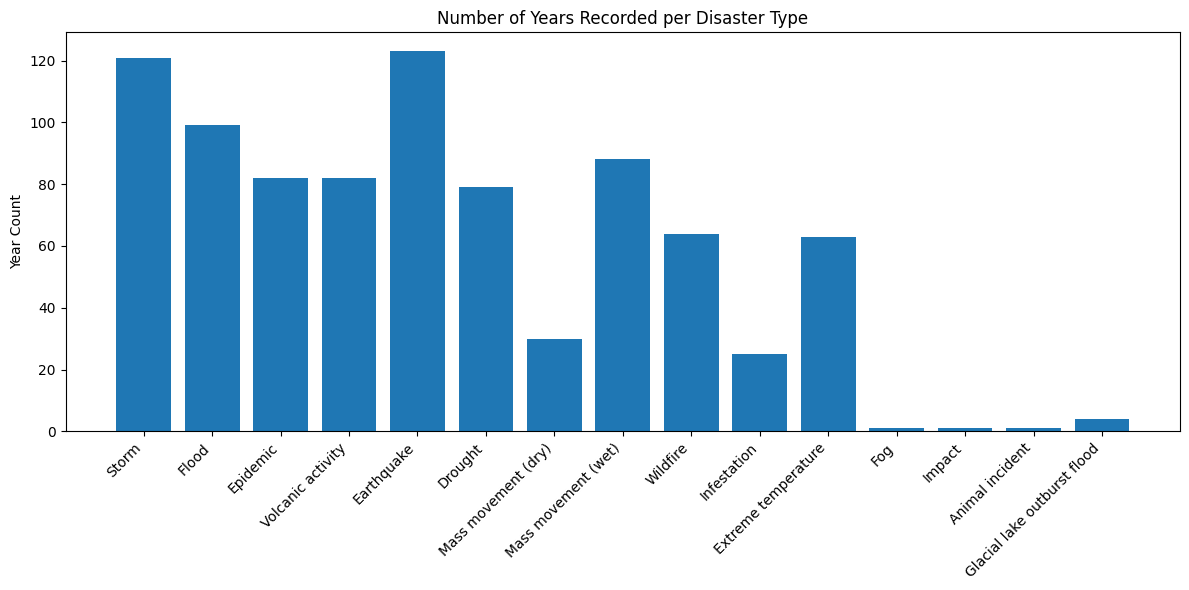

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

df = pd.read_csv("emdat.csv")
df = df.dropna(subset=["Disaster Type", "Start Year"])

type_years = {}

for i, row in df.iterrows():
    dtype = row["Disaster Type"]
    year = int(row["Start Year"])
    
    if dtype not in type_years:
        type_years[dtype] = set()
    type_years[dtype].add(year)

types = list(type_years.keys())
year_counts = [len(type_years[t]) for t in types]

plt.figure(figsize=(12,6))
plt.bar(types, year_counts)
plt.xticks(rotation=45, ha="right")
plt.title("Number of Years Recorded per Disaster Type")
plt.ylabel("Year Count")
plt.tight_layout()
plt.show()


findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font famil

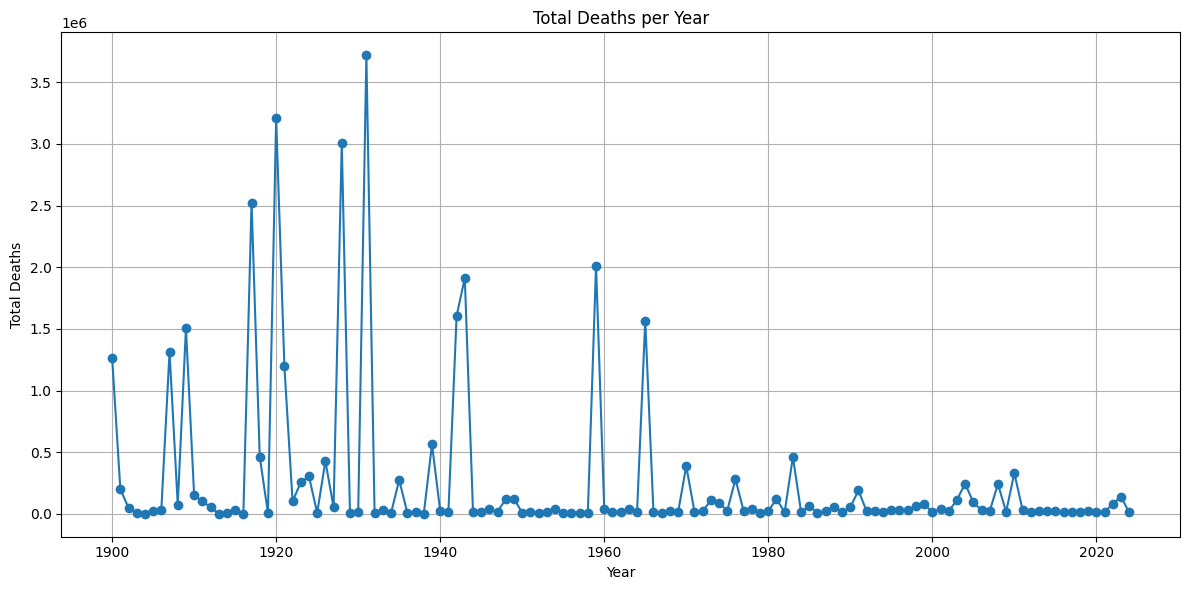

In [38]:
df = pd.read_csv("emdat.csv")
df = df.dropna(subset=["Start Year", "Total Deaths"])

year_deaths = {}

for i, row in df.iterrows():
    year = int(row["Start Year"])
    deaths = float(row["Total Deaths"])
    
    if year not in year_deaths:
        year_deaths[year] = deaths
    else:
        year_deaths[year] += deaths

years = sorted(year_deaths.keys())
deaths = [year_deaths[y] for y in years]

plt.figure(figsize=(12,6))
plt.plot(years, deaths, marker="o")
plt.title("Total Deaths per Year")
plt.xlabel("Year")
plt.ylabel("Total Deaths")
plt.grid(True)
plt.tight_layout()
plt.show()


findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font famil

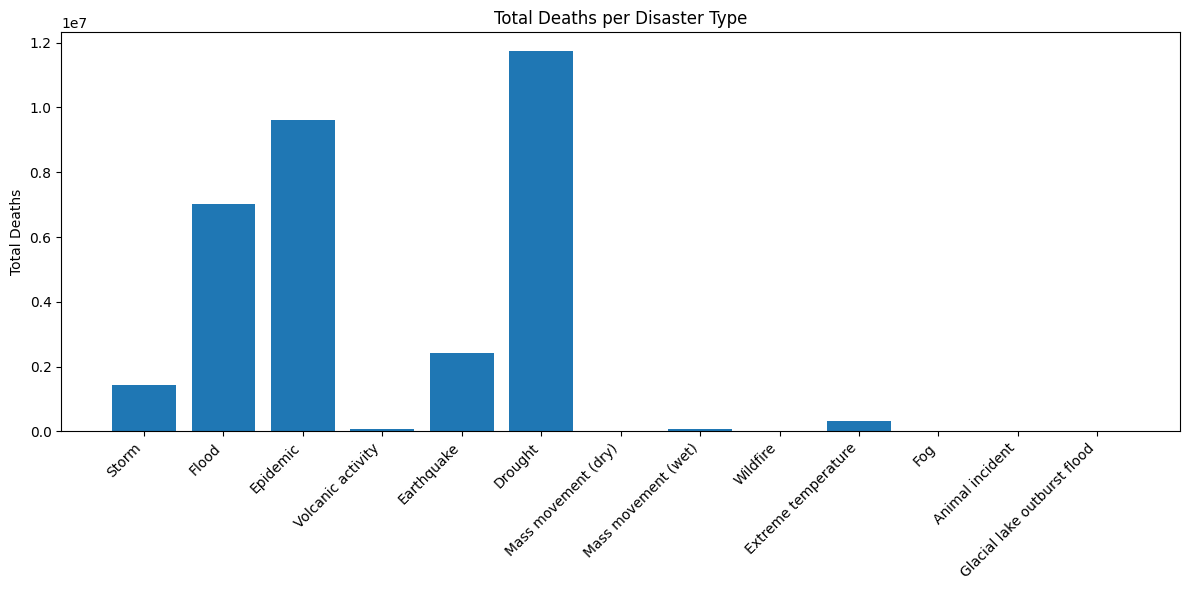

In [39]:
df = pd.read_csv("emdat.csv")
df = df.dropna(subset=["Disaster Type", "Total Deaths"])

type_deaths = {}

for i, row in df.iterrows():
    dtype = row["Disaster Type"]
    deaths = float(row["Total Deaths"])
    
    if dtype not in type_deaths:
        type_deaths[dtype] = deaths
    else:
        type_deaths[dtype] += deaths

types = list(type_deaths.keys())
deaths = [type_deaths[t] for t in types]

plt.figure(figsize=(12,6))
plt.bar(types, deaths)
plt.xticks(rotation=45, ha="right")
plt.title("Total Deaths per Disaster Type")
plt.ylabel("Total Deaths")
plt.tight_layout()
plt.show()


## 3Dにしたものをわざわざ2Dにしてみた

災害の種類と年数、年数と死者数、死者数と災害の種類のグラフをそれぞれ作った。

## 結果

2Dのものを３つ見て比べてもわかることがあるが3Dのものを１つにまとめてみると分かりやすくなった。